C:\Temp\ipykernel_22192\442923158.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(image)
c:\Users\Shivraj Sarode\anaconda3\envs\Phelma\Lib\site-packages\skimage\io\_plugins\matplotlib_plugin.py:158: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


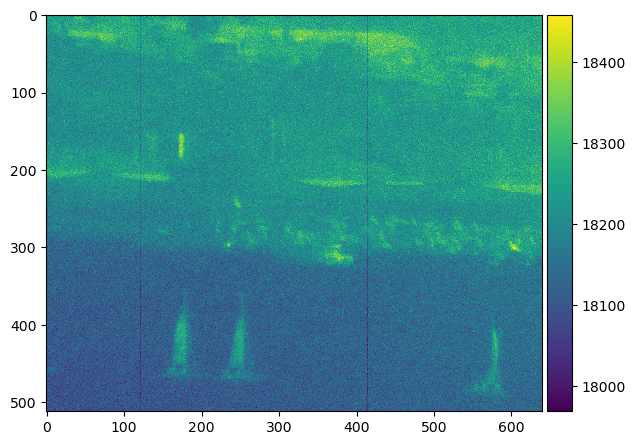

In [37]:
from skimage import io
import numpy as np
image=io.imread(r'C:\Users\Shivraj Sarode\Desktop\frame_0000_VGA_seq2_column2.png')
io.imshow(image)

#### Normalisation min-max simple : image_8bit = (image_16bit - min) / (max - min) * 255

C:\Temp\ipykernel_22192\290788792.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_final_simple)


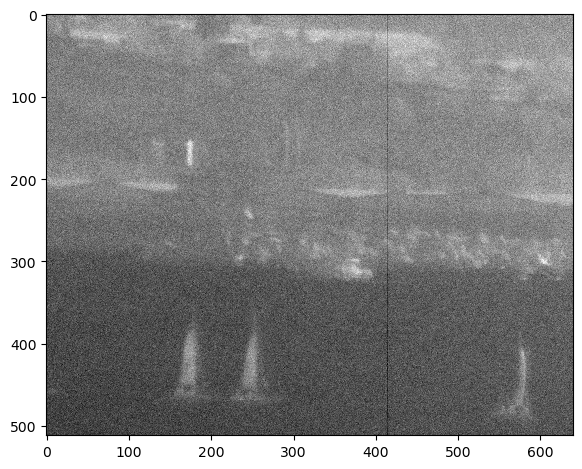

In [ ]:
img_final_simple = (image - np.min(image)) / (np.max(image) - np.min(image)) * 255
img_final_simple = img_final_simple.astype(np.uint8)
io.imshow(img_final_simple)

C:\Temp\ipykernel_22192\881963002.py:8: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_final)


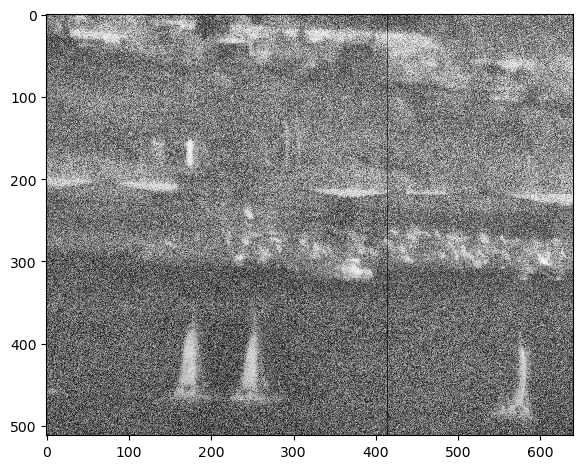

In [12]:
import cv2
import numpy as np

# Conversion nécessaire pour CLAHE (qui travaille en 8 bits)
img_8bit = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_final = clahe.apply(img_8bit)
io.imshow(img_final)

#### en utilisant des percentile 

In [13]:
def convert_to_8bit_for_viz(img_16bit):
    """""
    Convert 16 bits img into 8 bits using percentiles to not be biased by outliers  
    arg : img 
    return : converted img in 8 bits
    """""
    # 1. Utiliser des percentiles pour ignorer les pixels aberrants (très chauds ou très froids)
    # Cela permet de mieux voir les détails de la scène sans être ébloui par les extrêmes
    p2, p98 = np.percentile(img_16bit, (2, 98))
    img_clipped = np.clip(img_16bit, p2, p98)
    
    # 2. Normaliser entre 0 et 255
    img_8bit = ((img_clipped - p2) / (p98 - p2) * 255).astype(np.uint8)
    return img_8bit

img_percentile = convert_to_8bit_for_viz(image)

#### Compare 2 methods 

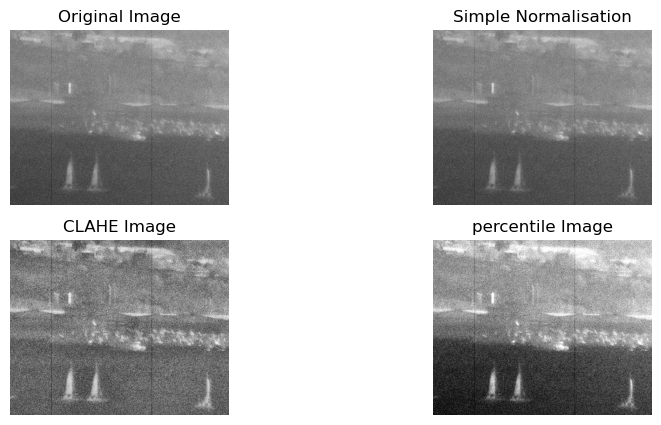

In [39]:
# plot images with both images 
import matplotlib.pyplot as plt
fig, axs = plt.subplots(2, 2, figsize=(10, 5))
axs = axs.flatten()
axs[0].imshow(image, cmap='gray')
axs[0].set_title('Original Image')
axs[0].axis('off')
axs[1].imshow(img_final_simple, cmap='gray')
axs[1].set_title('Simple Normalisation')
axs[1].axis('off')
axs[2].imshow(img_final, cmap='gray')
axs[2].set_title('CLAHE Image')
axs[2].axis('off')
axs[3].imshow(img_percentile, cmap='gray')
axs[3].set_title('percentile Image')
axs[3].axis('off')
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'imshow'

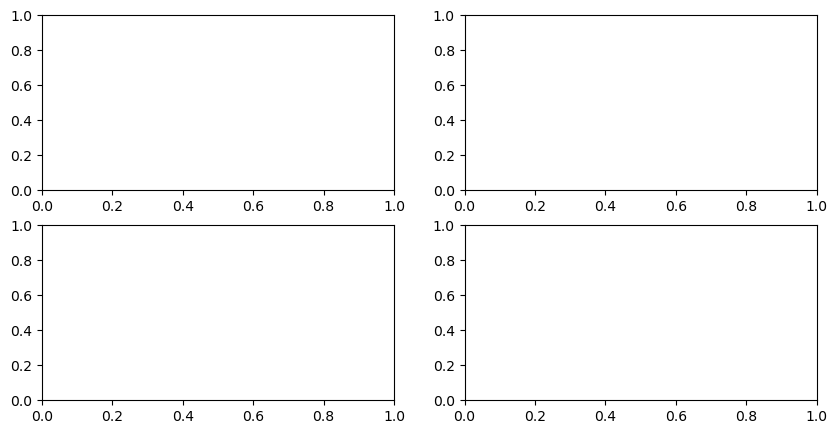

In [40]:
import cv2
import numpy as np

def remove_local_defects(image_path, kernel_size=20, threshold=30):
    # Load the image in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    # 1. Compute the local mean using a box filter
    local_mean = cv2.boxFilter(img, ddepth=-1, ksize=(kernel_size, kernel_size))
    
    # 2. Find absolute difference between original pixels and the local mean
    diff = cv2.absdiff(img, local_mean)
    
    # 3. Create a mask of the defects (where deviation from the mean is too high)
    _, defect_mask = cv2.threshold(diff, threshold, 255, cv2.THRESH_BINARY)
    
    # 4. Replace ONLY the defect pixels with the local mean value
    clean_img = np.where(defect_mask == 255, local_mean, img)
    
    return clean_img
clean_image = remove_local_defects(r'C:\Users\Shivraj Sarode\Desktop\frame_0000_VGA_seq2_column2.png')
fig, axs = plt.subplots(2, 2, figsize=(10, 5))
#axs = axs.flatten()
axs[0].imshow(image, cmap='gray')
axs[0].set_title('Original Image')
axs[0].axis('off')
axs[1].imshow(clean_image, cmap='gray')
axs[1].set_title('Simple Normalisation')
axs[1].axis('off')